<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week03%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%B6%84%EC%84%9D5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge

In [ ]:
import pandas as pd
mercari_df=pd.read_csv(r'C:\Users\woori\Desktop\ESAA\OB\과제\data\mercari_train.tsv', sep='\t')

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [ ]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


 이 Null 데이터는 이후에 적절한 문자열로 치환

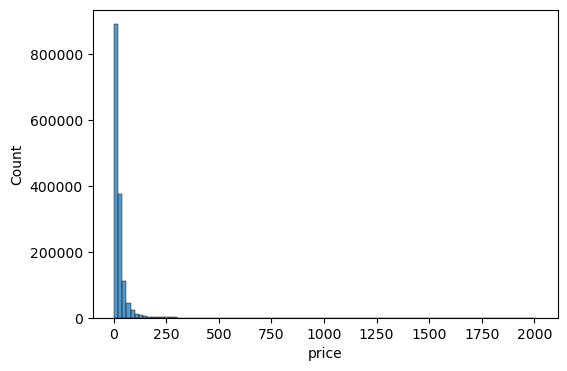

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df=mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df,bins=100)
plt.show()

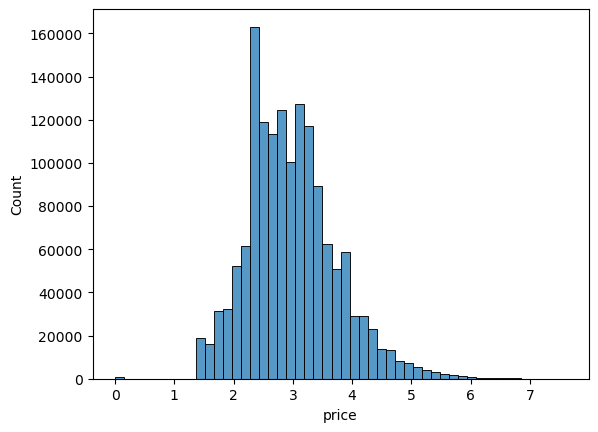

In [ ]:
import numpy as np

y_train_df=np.log1p(y_train_df)
sns.histplot(y_train_df,bins=50)
plt.show()

In [ ]:
mercari_df['price']=np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

0    2.397895
1    3.970292
2    2.397895
Name: price, dtype: float64

In [ ]:
print('Shipping 값 유형:\n',mercari_df['shipping'].value_counts())
print(' item 값 유형:\n',mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
 item 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [ ]:
boolean_cond=mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

82489

 적절한 값으로 변경해야 합
니다

categoryjname은 '/’로 분리된 카테고리를 하나의 문자열로 나
타내고 있습니다.  category_name의 /를 기준으로 단어를 토큰화해 각각 별도의
피처로 저장하고 이를 이용해 알고리즘을 학습시키겠습니다

In [ ]:
# apply 1am으여에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null','Other_Null','Other_Null']
mercari_df['cat_dae'],mercari_df['cat_jung'],mercari_df['cat_so']=\
    zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))
print('대분류 유형:\n',mercari_df['cat_dae'].value_counts())
print('중분류 유형:\n',mercari_df['cat_jung'].nunique())
print('소분류 유형:\n',mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 유형:
 114
소분류 유형:
 871


로 brand_name, category name, item_description 칼럼의 Null 값은 일괄적으로 ‘Other
Null’로 동일하게 변경

In [ ]:
mercari_df['brand_name']=mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name']=mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description']=mercari_df['item_description'].fillna(value='Other_Null')

mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

## 피처 인코딩과 피처 벡터화

선형 회귀의 경우
원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩을 적용

In [ ]:
print('brand name의 유형 건수: ',mercari_df['brand_name'].nunique())
print('brand name sample 5건: \n',mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수:  4810
brand name sample 5건: 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


In [ ]:
# 명료한 문자열로 돼 있습니다. 별도의 피처 벡터화 형태로 만들 필요 없이 인코딩 변환을 적용
print('name의 유형 건수: ',mercari_df['name'].nunique())
print('name sample 5건: \n',mercari_df['name'][:7])

name의 유형 건수:  1225273
name sample 5건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


Name 속성은 유형이 매우 많고, 적은 단어 위주의 텍스트 형태로 돼 있으므로 Count 기반으로 피처 벡터화 변환을 적용

cat_dae, catjung, cat_so 칼럼도 원一핫 인코딩을
적용하겠습니다.
shipping 칼럼은 배송비 무료 여부로서 0과 1, 두 가지 유형의 값을 가지고 있으며 item_condition_
id는 상품 상태로서 1, 2, 3, 4, 5의 다섯 가지 유형의 값을 가지고 있습니다. 이 두 칼럼 모두 원-핫 인
코딩을 적용

In [ ]:
pd.set_option('max_colwidth',200)
print('item_description 평균 문자열의 크기: ',mercari_df['item_description'].str.len().mean())
mercari_df['item_description'][:2]

item_description 평균 문자열의 크기:  145.71139703278507


0                                                                                                                                                                              No description yet
1    This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.
Name: item_description, dtype: object

In [ ]:
#평균 문자열이 145자로 비교적 크므로 해당 칼럼은 TF-IDF로 변환
cnt_vec=CountVectorizer()
X_name=cnt_vec.fit_transform(mercari_df.name)

tfidf_descp=TfidfVectorizer(max_features=50000,ngram_range=(1,3),
                            stop_words='english')
X_descp=tfidf_descp.fit_transform(mercari_df['item_description'])
print('name vectorization shape:',X_name.shape)
print('item_description vectorization shape: ',X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape:  (1482535, 50000)


CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태입니
다. 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 하고,
앞으■로 인코딩될 cat dae, catjung, cat_so, brand_name, shipping, item_condition_id도 모두
X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 합니다.

이를 위해서 이 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함
께 결합하도록 하겠습니다. 사이킷런은 원一핫 인코딩을 위해 OneHotEncoder와 LabelBinarizer 클
래스를 제공합니다. 이 중 LabelBinarizer 클래스는 희소 행렬 형태의 원-핫 인코딩 변환을 지원합
니다. 생성 시 sparse_out=True로 파라미터를 설정해주기만 하면 됩니다. 모든 인코딩 대상 칼럼은
LabelBinarizer를 이용해 희소 행렬 형태의 원-핫 인코딩으로 변환하겠습니다. 개별 칼럼으로 만들어
진 희소 행렬은 사이파이 패키지 sparse 모듈의 hstack( ) 함수를 이용해 결합하겠습니다. hstack( )
함수는 희소 행렬을 손쉽게 칼럼 레벨로 결합할 수 있게 해줍니다

In [ ]:
from sklearn.preprocessing import LabelBinarizer
lb_brand_name=LabelBinarizer(sparse_output=True)
X_brand=lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id=LabelBinarizer(sparse_output=True)
X_item_cond_id=lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping=LabelBinarizer(sparse_output=True)
X_shipping=lb_shipping.fit_transform(mercari_df['shipping'])

lb_cat_dae=LabelBinarizer(sparse_output=True)
X_cat_dae=lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung=LabelBinarizer(sparse_output=True)
X_cat_jung=lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so=LabelBinarizer(sparse_output=True)
X_cat_so=lb_cat_so.fit_transform(mercari_df['cat_so'])

In [ ]:
print(type(X_brand),type(X_item_cond_id),type(X_shipping))
print('X_btand shape:{0}, X_item_cond_id shape: {1}'.format(X_brand.shape,X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape: {1}'.format(X_shipping.shape,X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape: {1}'.format(X_cat_jung.shape,X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_btand shape:(1482535, 4810), X_item_cond_id shape: (1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape: (1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape: (1482535, 871)


만들어진 결합 데이터가 비교적 많은 메모리를 잡아먹기 때문에 개인용 PC에서 메모리 오류가 발
생할 수 있기에 del ‘객체 변수명’과 gc.collect()로 결합 데이터를 메모리에서 삭제합니다. 추후에 다
양한 모델을 적용하므로 그때마다 다시 결합해 해당 데이터 세트를 이용

In [ ]:
# 피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용해 모두 결합
from scipy.sparse import hstack
import gc

sparse_matrix_list=(X_name,X_descp,X_brand,X_item_cond_id,
                    X_shipping,X_cat_dae,X_cat_jung,X_cat_so)
X_features_sparse=hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse),X_features_sparse.shape)

del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


205

## 릿지 회귀 모델 구축 및 평가

평가함수 :낮은 가격(price)보다 높은 가격에서 오류가 발생할 경우 오류 값이 더 커지는 것을 억제하기 위해서  RMSLE(Root Mean Square Logarithmic Error) 방식


In [ ]:
def rmsle(y,y_pred):
    return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred),2)))

def evaluate_org_price(y_test,preds):
    preds_exmpm=np.expm1(preds)
    y_test_exmpm=np.expm1(y_test)

    rmsle_result=rmsle(y_test_exmpm,preds_exmpm)
    return rmsle_result

In [ ]:
import gc
from scipy.sparse import hstack

def model_train_predict(model,matrix_list):
    X=hstack(matrix_list).tocsr()
    X_train,X_test,y_train,y_test=train_test_split(X,mercari_df['price'],
    test_size=0.2,random_state=156)
    model.fit(X_train,y_train)
    preds=model.predict(X_test)
    del X, X_train,X_test,y_train
    gc.collect()
    return preds, y_test

Ridge를 이용해 Mercari Price의 회귀 예측을 수행하
겠습니다. 수행 전에 Merari 상품 가격 예측에 item_description과 같은 텍스트 형태의 속성이 얼마
나 영향을 미치는지 알아보겠습니다.

In [ ]:
linear_model=Ridge(solver='lsqr',fit_intercept=False)
sparse_matrix_list=(X_name,X_brand,X_cat_jung,X_shipping,X_cat_dae,X_cat_so)
linear_preds,y_test=model_train_predict(model=linear_model,
                                        matrix_list=sparse_matrix_list)
print('Item Description을 제외했을때 rmsle 값:',evaluate_org_price(y_test,linear_preds))


sparse_matrix_list=(X_descp,X_name,X_brand,X_cat_jung,X_shipping,X_cat_dae,X_cat_so)
linear_preds,y_test=model_train_predict(model=linear_model,
                                        matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:',evaluate_org_price(y_test,linear_preds))

Item Description을 제외했을때 rmsle 값: 0.5066144144007004
Item Description을 포함한 rmsle 값: 0.47176624713251947


## LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

In [ ]:
#from lightgbm import LGBMRegressor

#sparse_matrix_list=(X_descp,X_name,X_brand,X_cat_jung,X_shipping,X_cat_dae,X_cat_so)
#lgbm_model=LGBMRegressor(n_estimators=200,learning_rate=0.5,
#                         num_leaves=125,random_state=156)
#lgbm_preds,y_test=model_train_predict(model=lgbm_model,matrix_list=sparse_matrix_list)
#print('LightGBM rmsle 값:',evaluate_org_price(y_test,lgbm_preds))

In [ ]:
#preds=lgbm_preds*0.45+linear_preds*0.55
#print('LightGBM과 Ridge를 앙상블한 최종 rmsle 값:',evaluate_org_price(y_test,preds))